# Check distribution of ESCO occupations & GBN shares within ISCO Groups
Felix Zaussinger | 19.04.2022

## Core Analysis Goal(s)
1. Check how many ESCO occupations fall into the various ISCO groups
2. Check the distribution of GBN shares within ISCO groups
3. Decide whether the (unweighted) mean or median is the better central estimate for
the time being.

## Key Insight(s)
1.
2.
3.

In [209]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths(fn_config_path="paths_config.yml")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
from src import utils, stats_utils, plotting_utils
from src.data.framework import OccFramework

Configuration files

In [211]:
fn_config_path = "paths_config.yml"
fn_config_data = "data_config.yml"
fn_config_model = "model_config.yml"
fn_config_vis = "vis_config.yml"

Code ...

In [212]:
of = OccFramework(fn_config_path=fn_config_path, fn_config_data=fn_config_data)

Check distribution of ESCO occupations within ISCO groups

In [213]:
of.combine_occupation_metadata()

INFO:src.data.framework:Creating occupation-skills matrix.


C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,conceptType,conceptUri,iscoGroup,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,regulatedProfessionNote,scopeNote,definition,inScheme,description,code,isco_level_4,isco_level_1,isco_level_2,isco_level_3,isco_label_1,isco_label_2,isco_label_3,isco_label_4,n_total_specific_skills,n_green_specific_skills_esco,share_green_esco,n_brown_specific_skills_esco,share_brown_esco,n_neutral_specific_skills_esco,share_neutral_esco,gbn_classification_esco,onet_code,title_gtp,occupation_type,n_new_green_tasks_gtp,n_existing_green_tasks_gtp,n_non_green_tasks_gtp,share_green_gtp,title_vona2018,share_green_vona2018,total_spec_tasks_vona2018,green_spec_tasks_vona2018,id,concept_uri,preferred_label,onet_occupation,is_brown_onet,is_green_onet,is_neutral_onet,gbn_classification_onet
0,Occupation,http://data.europa.eu/esco/occupation/00030d09...,2654,technical director,technical and operations director\nhead of tec...,NaN,released,2016-07-05T13:58:41Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Technical directors realise the artistic visio...,2654.1.7,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",8,0,0.000000,0,0.0,8,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
1,Occupation,http://data.europa.eu/esco/occupation/1a7fb683...,2654,video and motion picture director,television director\nfilm maker\nseries direct...,NaN,released,2017-01-17T13:59:29Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture directors are respons...,2654.1.8,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",39,0,0.000000,0,0.0,39,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
2,Occupation,http://data.europa.eu/esco/occupation/2f372afe...,2654,performance lighting director,television lighting supervisor\nTV lighting su...,NaN,released,2016-07-05T13:46:52Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/occu...,Performance lighting directors determine what ...,2654.1.4,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",38,2,0.052632,0,0.0,36,0.947368,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
3,Occupation,http://data.europa.eu/esco/occupation/30b25ee4...,2654,animation director,animation process director\ncartoon animation ...,NaN,released,2021-03-31T15:31:28.501Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Animation directors supervise and recruit mult...,2654.1.1,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",41,0,0.000000,0,0.0,41,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
4,Occupation,http://data.europa.eu/esco/occupation/3b6bea7d...,2654,video and motion picture producer,video & motion picture producer\nmovie produce...,NaN,released,2017-01-17T13:58:37Z,http://data.europa.eu/esco/regulated-professio...,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Video and motion picture producers supervise t...,2654.3.2,2654,2,26,265,Professionals,"Legal, social and cultural professionals",Creative and performing artists,"Film, stage and related directors and producers",39,0,0.000000,0,0.0,39,1.000000,neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [214]:
omd = of.occupation_metadata

In [253]:
shares_by_isco = of.aggregate_occ_data_by_isco()
shares_by_isco

,isco_level_1,isco_label_1,share_green_gtp_mean,n_occ_esco_sum,share_green_esco_mean,share_brown_esco_mean,share_neutral_esco_mean,isco_code,isco_level_2,isco_label_2,isco_level_3,isco_label_3,isco_level_4,isco_label_4
0,0,Armed forces occupations,0.000000,21.0,0.002783,0.001642,0.995575,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Managers,0.238567,338.0,0.033836,0.005270,0.960894,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Professionals,0.321054,846.0,0.044372,0.009094,0.946534,2,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Technicians and associate professionals,0.321925,653.0,0.048199,0.010582,0.941218,3,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Clerical support workers,0.164054,89.0,0.024906,0.003998,0.971096,4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,NaN,NaN,0.000000,1.0,0.115385,0.000000,0.884615,9613,NaN,NaN,NaN,NaN,9613,Sweepers and related labourers
599,NaN,NaN,0.000000,2.0,0.000000,0.000000,1.000000,9621,NaN,NaN,NaN,NaN,9621,"Messengers, package deliverers and luggage por..."
600,NaN,NaN,0.000000,1.0,0.041667,0.000000,0.958333,9622,NaN,NaN,NaN,NaN,9622,Odd job persons
601,NaN,NaN,0.000000,2.0,0.104167,0.000000,0.895833,9623,NaN,NaN,NaN,NaN,9623,Meter readers and vending-machine collectors


Pivot occupation metadata to long format

In [215]:
value_vars = ["share_green_esco", "share_green_gtp", "share_brown_esco",]
id_vars = set(omd.columns.values.tolist()) - set(value_vars)
var_name = "variable"
value_name = "occupational_share"

omd_long = omd.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name=var_name,
    value_name=value_name

)

In [216]:
omd_long

,gbn_classification_esco,inScheme,n_neutral_specific_skills_esco,n_new_green_tasks_gtp,isco_label_4,isco_label_1,isco_level_3,n_total_specific_skills,conceptUri,n_existing_green_tasks_gtp,definition,green_spec_tasks_vona2018,occupation_type,share_neutral_esco,title_vona2018,n_non_green_tasks_gtp,is_brown_onet,modifiedDate,isco_label_2,regulatedProfessionNote,status,isco_level_2,total_spec_tasks_vona2018,hiddenLabels,share_green_vona2018,description,onet_code,onet_occupation,isco_level_4,is_neutral_onet,preferredLabel,n_brown_specific_skills_esco,scopeNote,concept_uri,is_green_onet,title_gtp,isco_level_1,code,iscoGroup,id,preferred_label,gbn_classification_onet,altLabels,conceptType,n_green_specific_skills_esco,isco_label_3,variable,occupational_share
0,neutral,http://data.europa.eu/esco/concept-scheme/occu...,8,NaN,"Film, stage and related directors and producers",Professionals,265,8,http://data.europa.eu/esco/occupation/00030d09...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,False,2016-07-05T13:58:41Z,"Legal, social and cultural professionals",http://data.europa.eu/esco/regulated-professio...,released,26,NaN,NaN,NaN,Technical directors realise the artistic visio...,NaN,NaN,2654,True,technical director,0,NaN,NaN,False,NaN,2,2654.1.7,2654,NaN,NaN,neutral,technical and operations director\nhead of tec...,Occupation,0,Creative and performing artists,share_green_esco,0.000000
1,neutral,http://data.europa.eu/esco/concept-scheme/memb...,39,NaN,"Film, stage and related directors and producers",Professionals,265,39,http://data.europa.eu/esco/occupation/1a7fb683...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,False,2017-01-17T13:59:29Z,"Legal, social and cultural professionals",http://data.europa.eu/esco/regulated-professio...,released,26,NaN,NaN,NaN,Video and motion picture directors are respons...,NaN,NaN,2654,True,video and motion picture director,0,NaN,NaN,False,NaN,2,2654.1.8,2654,NaN,NaN,neutral,television director\nfilm maker\nseries direct...,Occupation,0,Creative and performing artists,share_green_esco,0.000000
2,neutral,http://data.europa.eu/esco/concept-scheme/occu...,36,NaN,"Film, stage and related directors and producers",Professionals,265,38,http://data.europa.eu/esco/occupation/2f372afe...,NaN,NaN,NaN,NaN,0.947368,NaN,NaN,False,2016-07-05T13:46:52Z,"Legal, social and cultural professionals",http://data.europa.eu/esco/regulated-professio...,released,26,NaN,NaN,NaN,Performance lighting directors determine what ...,NaN,NaN,2654,True,performance lighting director,0,NaN,NaN,False,NaN,2,2654.1.4,2654,NaN,NaN,neutral,television lighting supervisor\nTV lighting su...,Occupation,2,Creative and performing artists,share_green_esco,0.052632
3,neutral,http://data.europa.eu/esco/concept-scheme/memb...,41,NaN,"Film, stage and related directors and producers",Professionals,265,41,http://data.europa.eu/esco/occupation/30b25ee4...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,False,2021-03-31T15:31:28.501Z,"Legal, social and cultural professionals",http://data.europa.eu/esco/regulated-professio...,released,26,NaN,NaN,NaN,Animation directors supervise and recruit mult...,NaN,NaN,2654,True,animation director,0,NaN,NaN,False,NaN,2,2654.1.1,2654,NaN,NaN,neutral,animation process director\ncartoon animation ...,Occupation,0,Creative and performing artists,share_green_esco,0.000000
4,neutral,http://data.europa.eu/esco/concept-scheme/memb...,39,NaN,"Film, stage and related directors and producers",Professionals,265,39,http://data.europa.eu/esco/occupation/3b6bea7d...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,False,2017-01-17T13:58:37Z,"Legal, social and cultural professionals",http://data.europa.eu/esco/regulated-professio...,released,26,NaN,NaN,NaN,Video and motion picture producers supervise t...,NaN,NaN,2654,True,video and motion picture producer,0,NaN,NaN,False,NaN,2,2654.3.2,2654,NaN,NaN,neutral,video & motion picture producer\nmovie produce...,Occupation,0,Creative and performing artists,share_green_esco,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

Counts of individual observations per isco group and share category

In [248]:
isco_level = "isco_label_2"

df_count_by_category = (
    omd_long.groupby([isco_level, var_name])
        .count()
        .loc[:, value_name]
        .reset_index()
)

new_names = {"variable": "category", value_name: "n_obs"}
df_count_by_category = df_count_by_category.rename(columns=new_names)

In [262]:
shares_by_isco

,isco_level_1,isco_label_1,share_green_gtp_mean,n_occ_esco_sum,share_green_esco_mean,share_brown_esco_mean,share_neutral_esco_mean,isco_code,isco_level_2,isco_label_2,isco_level_3,isco_label_3,isco_level_4,isco_label_4
0,0,Armed forces occupations,0.000000,21.0,0.002783,0.001642,0.995575,0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Managers,0.238567,338.0,0.033836,0.005270,0.960894,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Professionals,0.321054,846.0,0.044372,0.009094,0.946534,2,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Technicians and associate professionals,0.321925,653.0,0.048199,0.010582,0.941218,3,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Clerical support workers,0.164054,89.0,0.024906,0.003998,0.971096,4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,NaN,NaN,0.000000,1.0,0.115385,0.000000,0.884615,9613,NaN,NaN,NaN,NaN,9613,Sweepers and related labourers
599,NaN,NaN,0.000000,2.0,0.000000,0.000000,1.000000,9621,NaN,NaN,NaN,NaN,9621,"Messengers, package deliverers and luggage por..."
600,NaN,NaN,0.000000,1.0,0.041667,0.000000,0.958333,9622,NaN,NaN,NaN,NaN,9622,Odd job persons
601,NaN,NaN,0.000000,2.0,0.104167,0.000000,0.895833,9623,NaN,NaN,NaN,NaN,9623,Meter readers and vending-machine collectors


In [264]:
merge_cols = [var + "_mean" for var in value_vars] + [isco_level]
df_count_by_category_merged = df_count_by_category.merge\
    (right=shares_by_isco[merge_cols], on=isco_level, how="left")

In [268]:
by = ["share_green_gtp_mean", isco_level]
df_count_by_category_merged.sort_values(by=by, ascending=False)

,isco_label_2,category,n_obs,share_green_esco_mean,share_green_gtp_mean,share_brown_esco_mean
105,Refuse workers and other elementary workers,share_brown_esco,16,0.135810,1.0,0.004808
106,Refuse workers and other elementary workers,share_green_esco,16,0.135810,1.0,0.004808
107,Refuse workers and other elementary workers,share_green_gtp,3,0.135810,1.0,0.004808
63,Information and communications technology prof...,share_brown_esco,69,0.004141,1.0,0.000216
64,Information and communications technology prof...,share_green_esco,69,0.004141,1.0,0.000216
...,...,...,...,...,...,...
7,"Armed forces occupations, other ranks",share_green_esco,5,0.004545,0.0,0.006897
8,"Armed forces occupations, other ranks",share_green_gtp,0,0.004545,0.0,0.006897
3,"Agricultural, forestry and fishery labourers",share_brown_esco,14,0.141813,0.0,0.004625
4,"Agricultural, forestry and fishery labourers",share_green_esco,14,0.141813,0.0,0.004625


In [269]:
by = ["share_green_esco_mean", isco_level]
df_count_by_category_merged.sort_values(by=by, ascending=False)

,isco_label_2,category,n_obs,share_green_esco_mean,share_green_gtp_mean,share_brown_esco_mean
75,Market-oriented skilled agricultural workers,share_brown_esco,27,0.240285,0.263158,0.001836
76,Market-oriented skilled agricultural workers,share_green_esco,27,0.240285,0.263158,0.001836
77,Market-oriented skilled agricultural workers,share_green_gtp,2,0.240285,0.263158,0.001836
3,"Agricultural, forestry and fishery labourers",share_brown_esco,14,0.141813,0.000000,0.004625
4,"Agricultural, forestry and fishery labourers",share_green_esco,14,0.141813,0.000000,0.004625
...,...,...,...,...,...,...
85,Non-commissioned armed forces officers,share_green_esco,4,0.000000,0.000000,0.000000
86,Non-commissioned armed forces officers,share_green_gtp,0,0.000000,0.000000,0.000000
45,General and keyboard clerks,share_brown_esco,5,0.000000,0.000000,0.000000
46,General and keyboard clerks,share_green_esco,5,0.000000,0.000000,0.000000


In [270]:
by = ["share_brown_esco_mean", isco_level]
df_count_by_category_merged.sort_values(by=by, ascending=False)

,isco_label_2,category,n_obs,share_green_esco_mean,share_green_gtp_mean,share_brown_esco_mean
81,"Metal, machinery and related trades workers",share_brown_esco,107,0.013396,0.171342,0.097807
82,"Metal, machinery and related trades workers",share_green_esco,107,0.013396,0.171342,0.097807
83,"Metal, machinery and related trades workers",share_green_gtp,8,0.013396,0.171342,0.097807
117,Stationary plant and machine operators,share_brown_esco,260,0.038865,0.052419,0.097545
118,Stationary plant and machine operators,share_green_esco,260,0.038865,0.052419,0.097545
...,...,...,...,...,...,...
22,"Chief executives, senior officials and legisla...",share_green_esco,25,0.013438,0.117647,0.000000
23,"Chief executives, senior officials and legisla...",share_green_gtp,3,0.013438,0.117647,0.000000
18,Business and administration professionals,share_brown_esco,130,0.022285,0.234804,0.000000
19,Business and administration professionals,share_green_esco,130,0.022285,0.234804,0.000000


<AxesSubplot:xlabel='n_obs', ylabel='isco_label_2'>

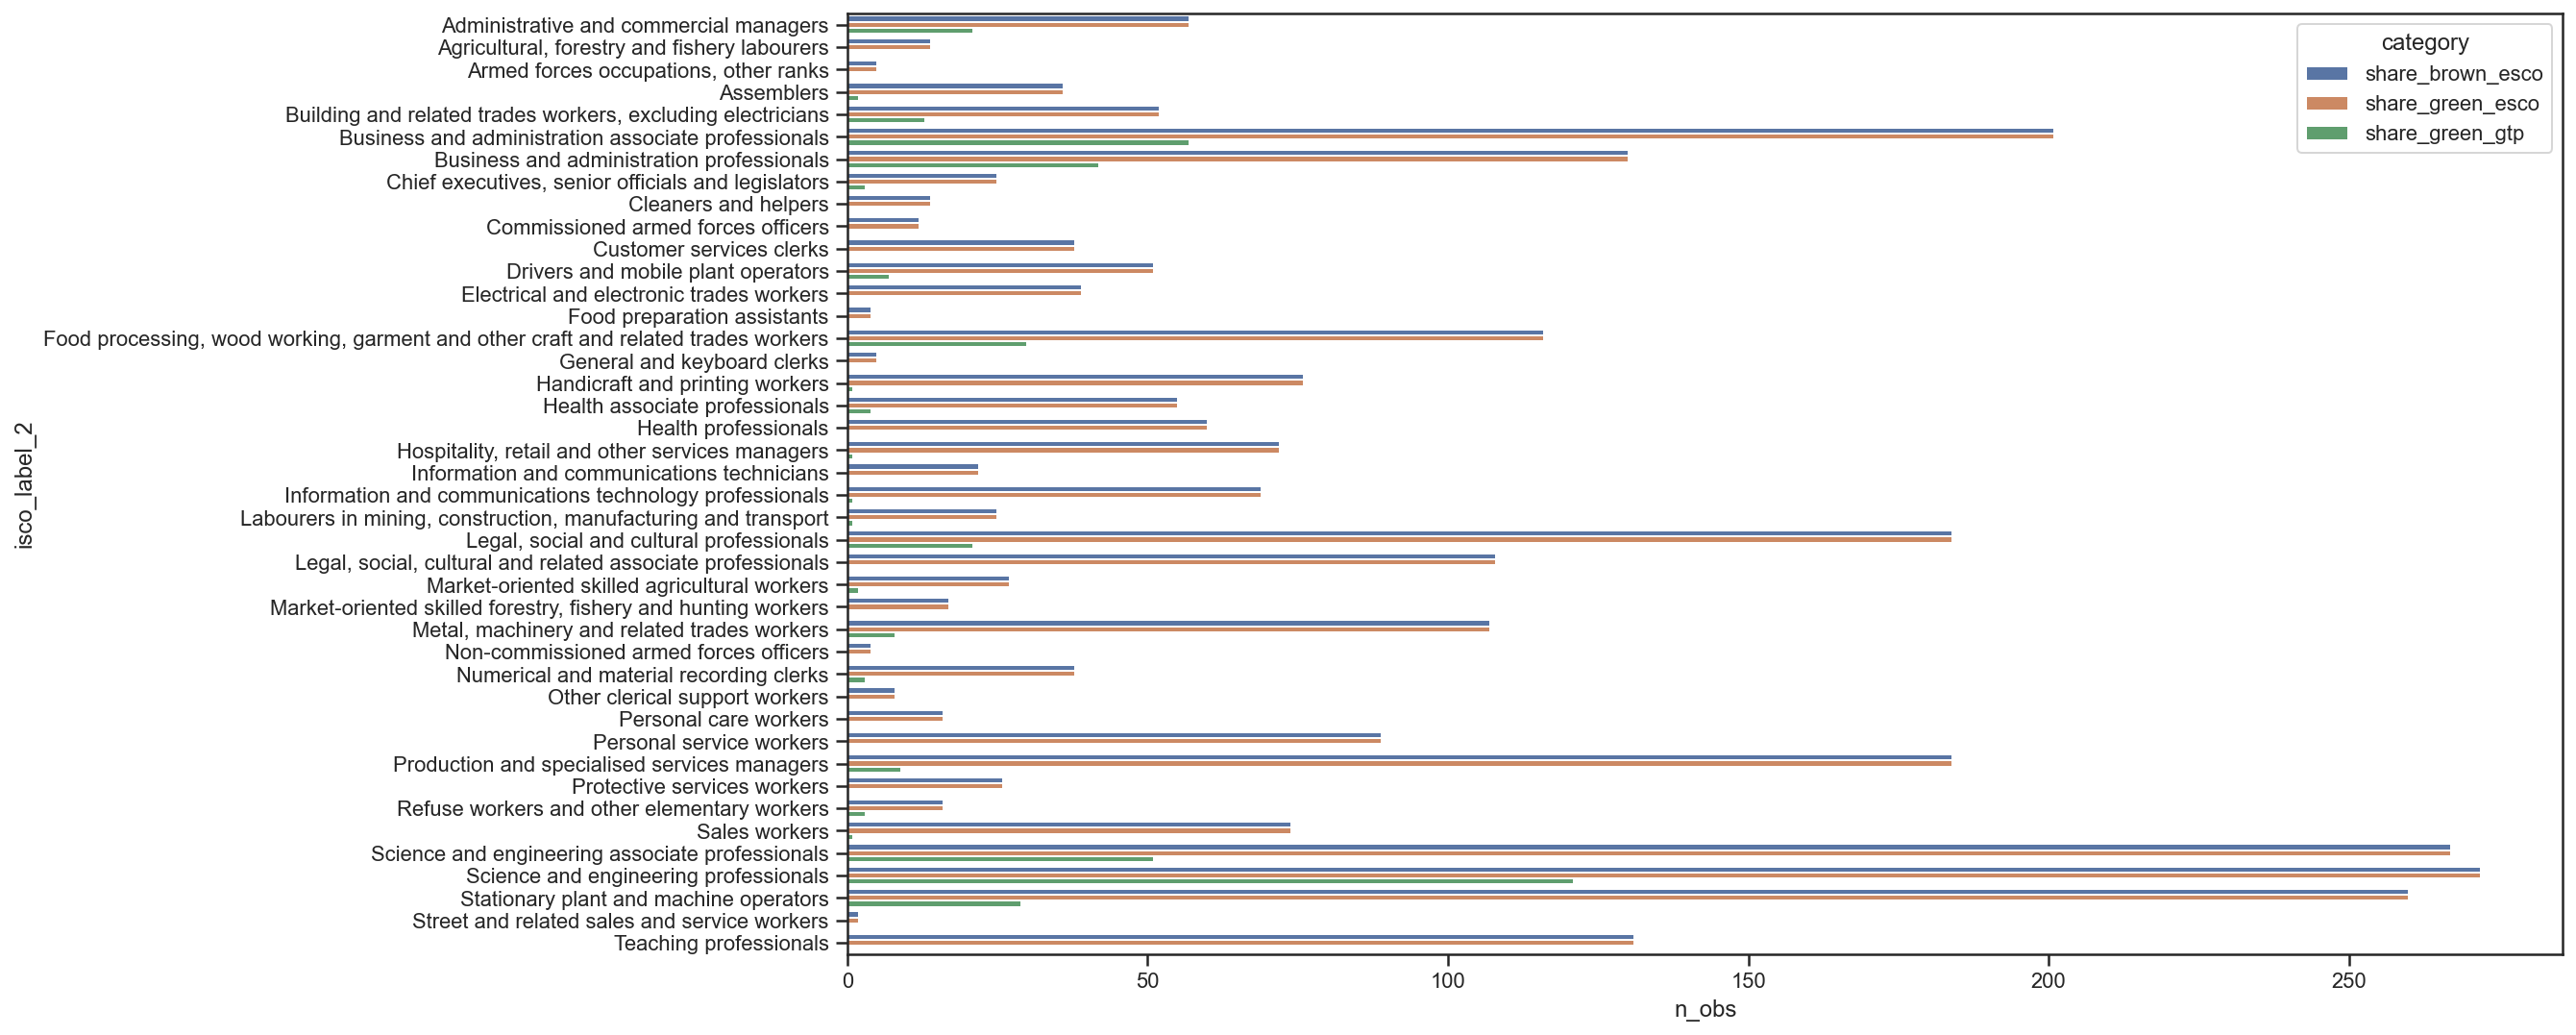

In [243]:
sns.barplot(
    data=df_count_by_category,
    x="n_obs",
    y=isco_level,
    hue="category",
)

Plot mean and median of occupational G/B share distributions by ISCO group

ISCO 2D, differentiated between esco/gtp green and esco brown

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_10908\191927905.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


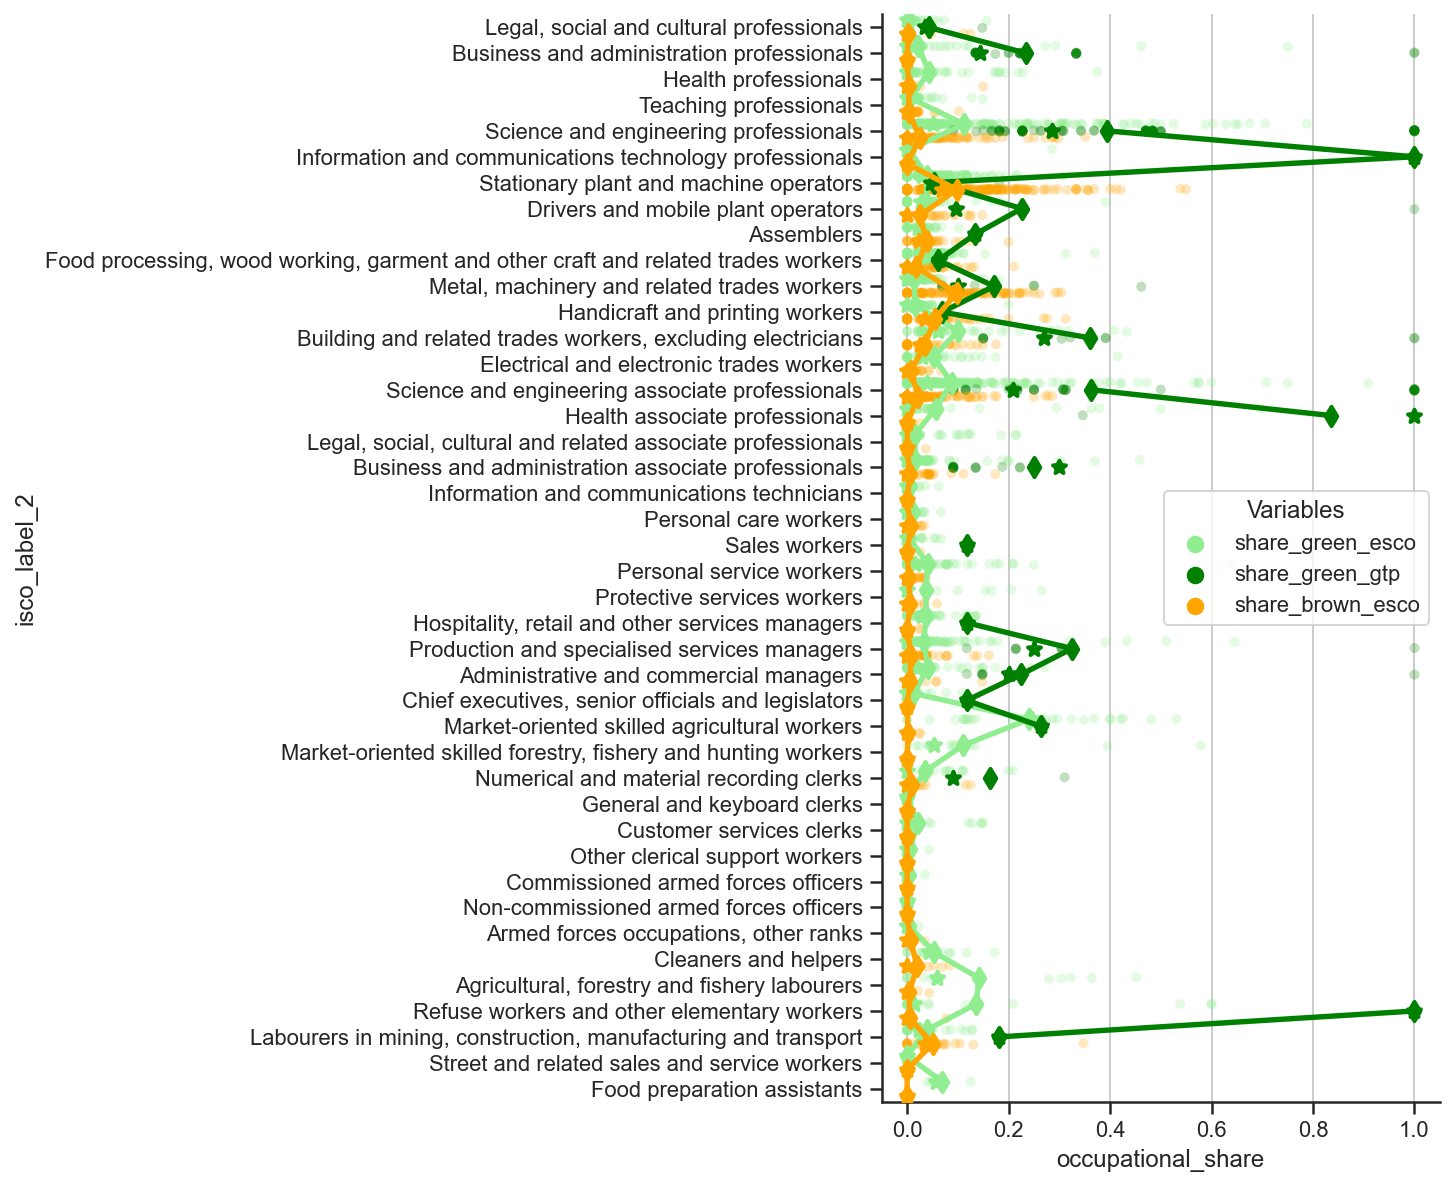

In [224]:
# params
y_var = "isco_label_2"
x_var = value_name
data = omd_long
figsize = (5, 10)

# figure
colors = ["lightgreen", "green", "orange"]
dodge_pp = .8 - .8 / 3

f, ax = plt.subplots(figsize=figsize)

sns.stripplot(
    y=y_var,
    x=x_var,
    hue=var_name,
    data=data,
    ax=ax,
    dodge=True,
    alpha=.25,
    zorder=1,
    palette=colors
)

sns.pointplot(
    y=y_var,
    x=x_var,
    hue=var_name,
    data=data,
    estimator=np.mean,
    ci=None,
    join=True,
    linewidth=0.5,
    dodge=dodge_pp,
    markers="d",
    ax=ax,
    palette=colors,
    edgecolor="k"
)

sns.pointplot(
    y=y_var,
    x=x_var,
    hue=var_name,
    data=data,
    estimator=np.median,
    ci=None,
    join=False,
    dodge=dodge_pp,
    markers="*",
    ax=ax,
    palette=colors,
    edgecolor="k"
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title="Variables")
#plotting_utils.move_legend_to_right(ax)

sns.despine()
ax.grid(axis="x")

plt.tight_layout()

Shares by 3D isco groups, plotted separately

In [ ]:
def plot_esco_gbn_shares_in_isco_groups(data, y_var, x_var, figsize=(10, 20)):

    # infer order (sorted by median in descending order)
    plotting_order = (
        data.loc[:, (y_var, x_var)]
        .groupby(y_var)
        .mean()
        .sort_values(by=x_var, ascending=False)
        .index.values
    )

    # figure
    f, ax = plt.subplots(figsize=figsize)

    sns.stripplot(
        y=y_var,
        x=x_var,
        color=".3",
        data=data,
        ax=ax,
        alpha=.3,
        order=plotting_order,
        zorder=1
    )

    sns.pointplot(
        y=y_var,
        x=x_var,
        data=data,
        estimator=np.mean,
        ci="sd",
        join=False,
        markers="d",
        linewidth=.1,
        ax=ax,
        order=plotting_order
    )

    sns.pointplot(
        y=y_var,
        x=x_var,
        data=data,
        estimator=np.median,
        ci=None,
        join=False,
        markers="d",
        color="r",
        ax=ax,
        order=plotting_order
    )

    sns.despine()
    ax.grid(axis="x")
    return ax

<AxesSubplot:xlabel='share_green_esco', ylabel='isco_label_3'>

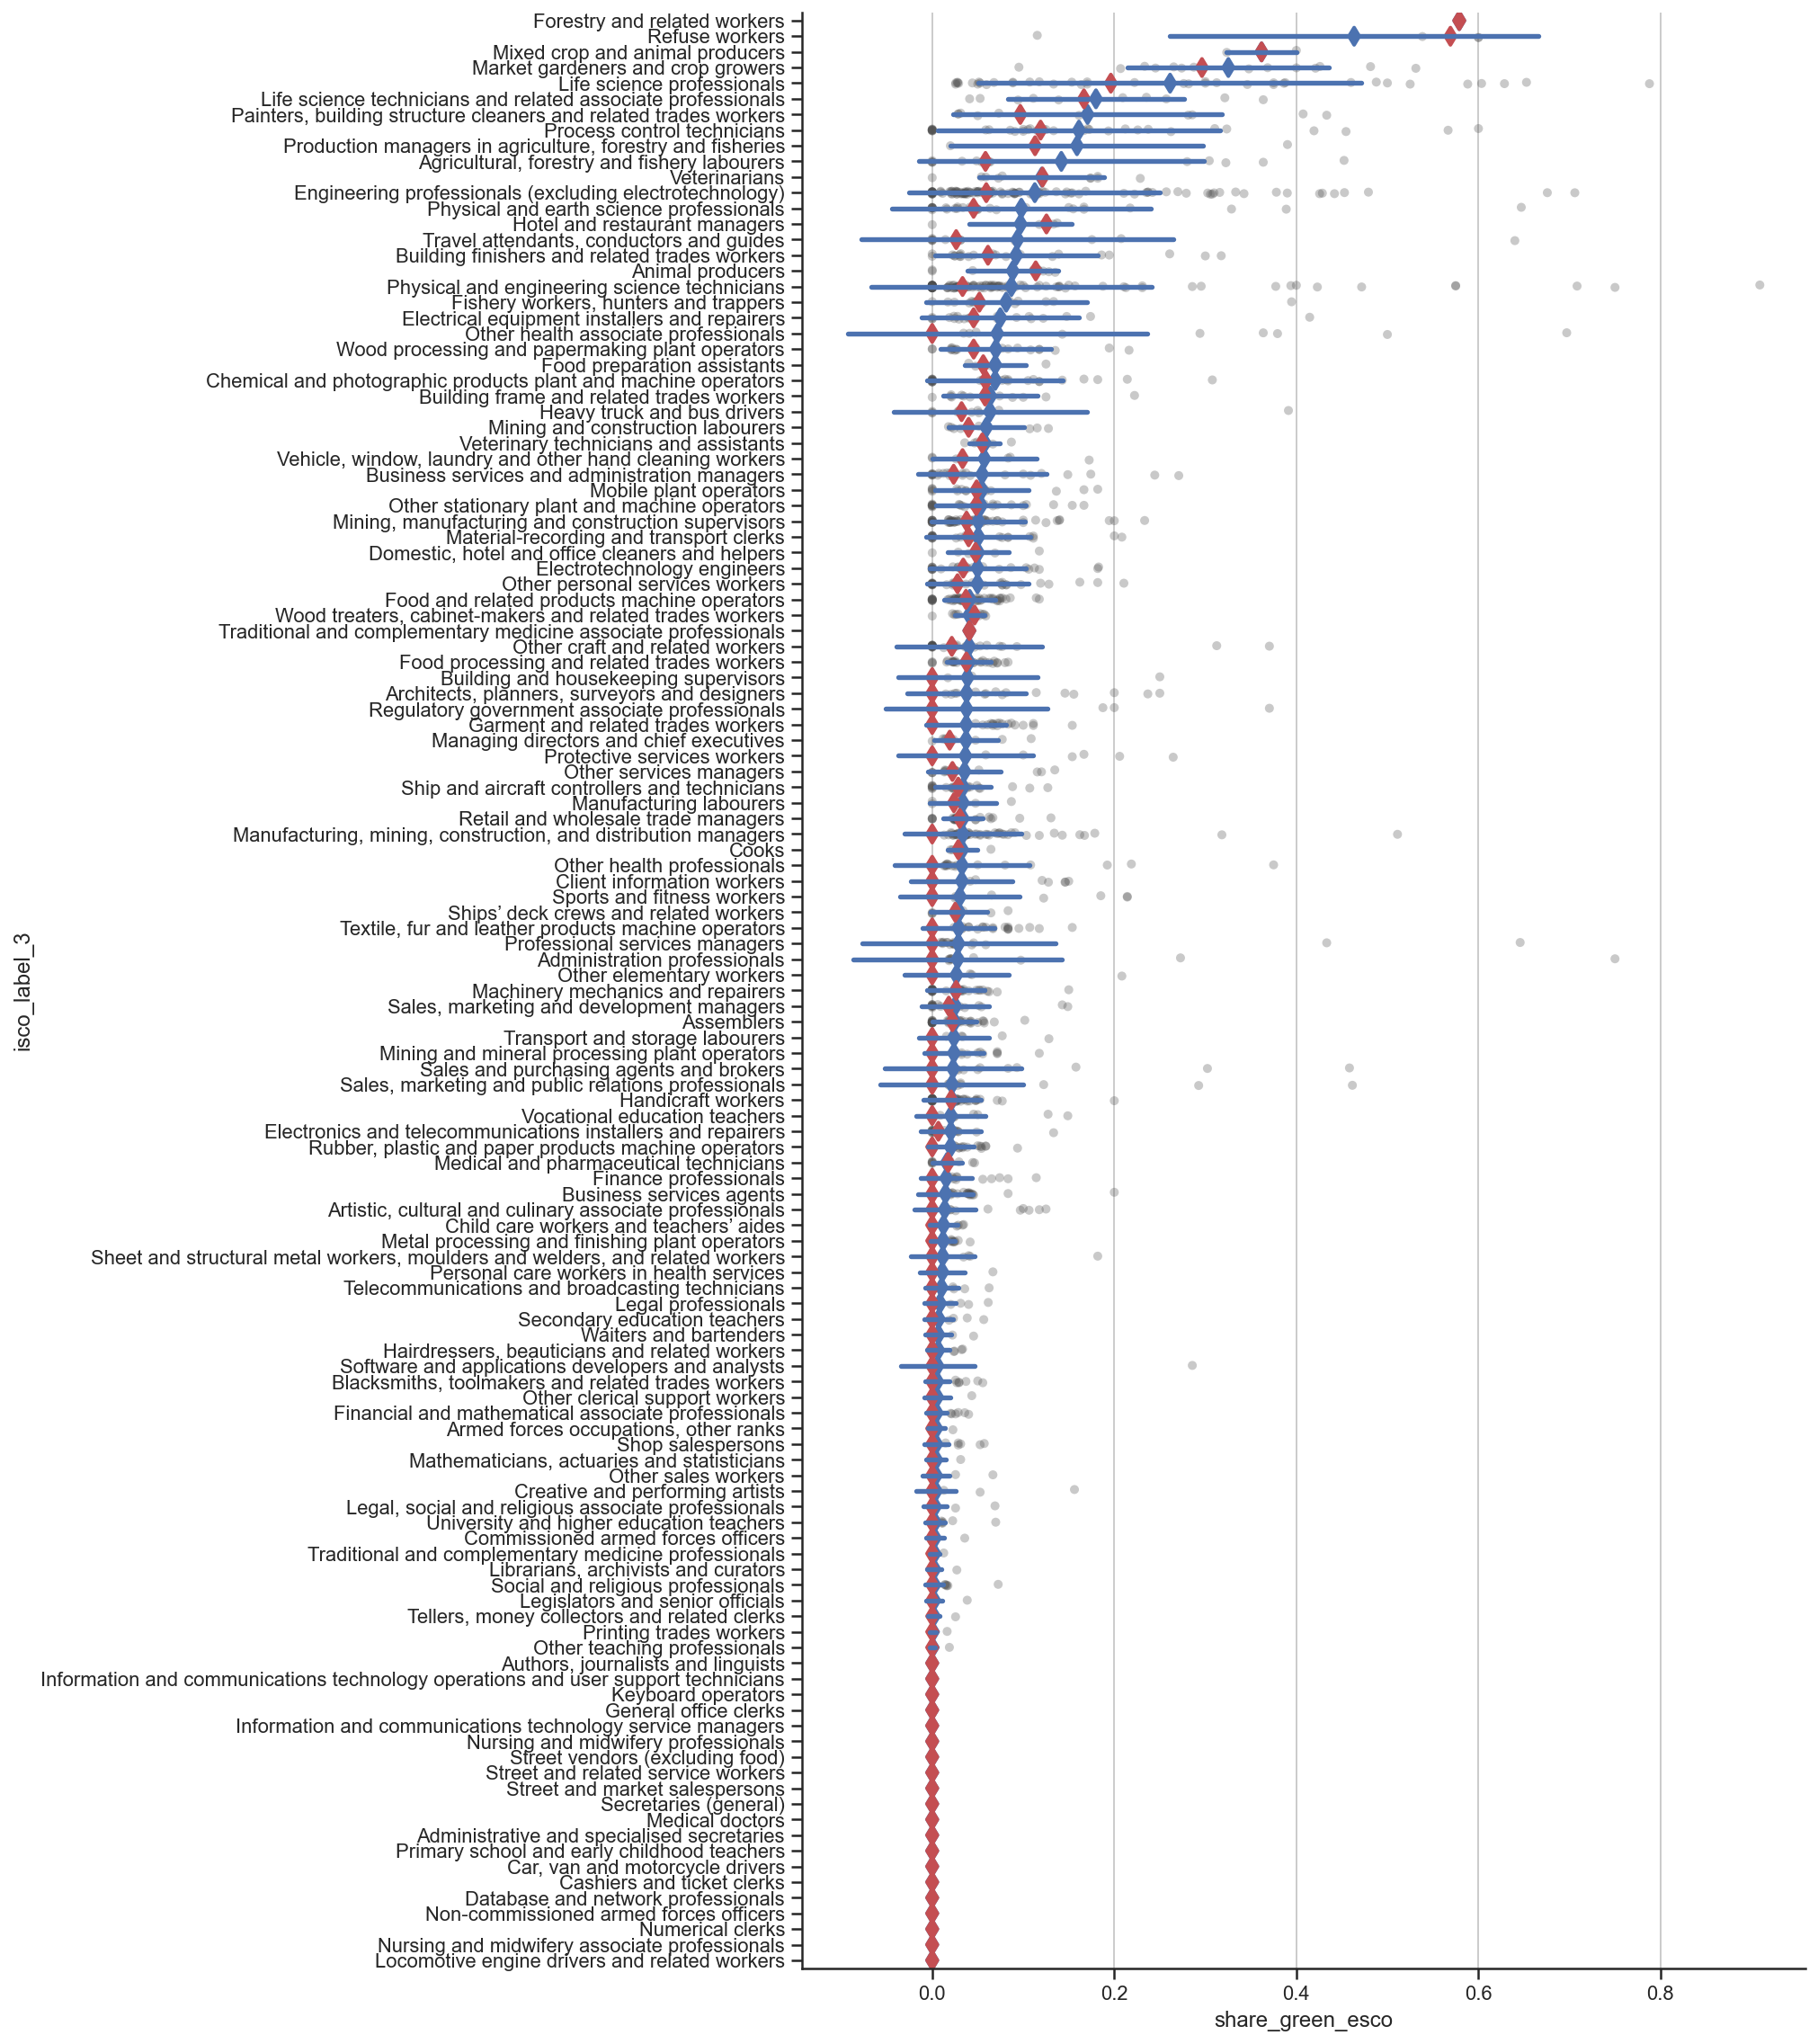

In [219]:
plot_esco_gbn_shares_in_isco_groups(data=omd, x_var="share_green_esco",
                                    y_var="isco_label_3", figsize=(10, 20))

<AxesSubplot:xlabel='share_green_gtp', ylabel='isco_label_3'>

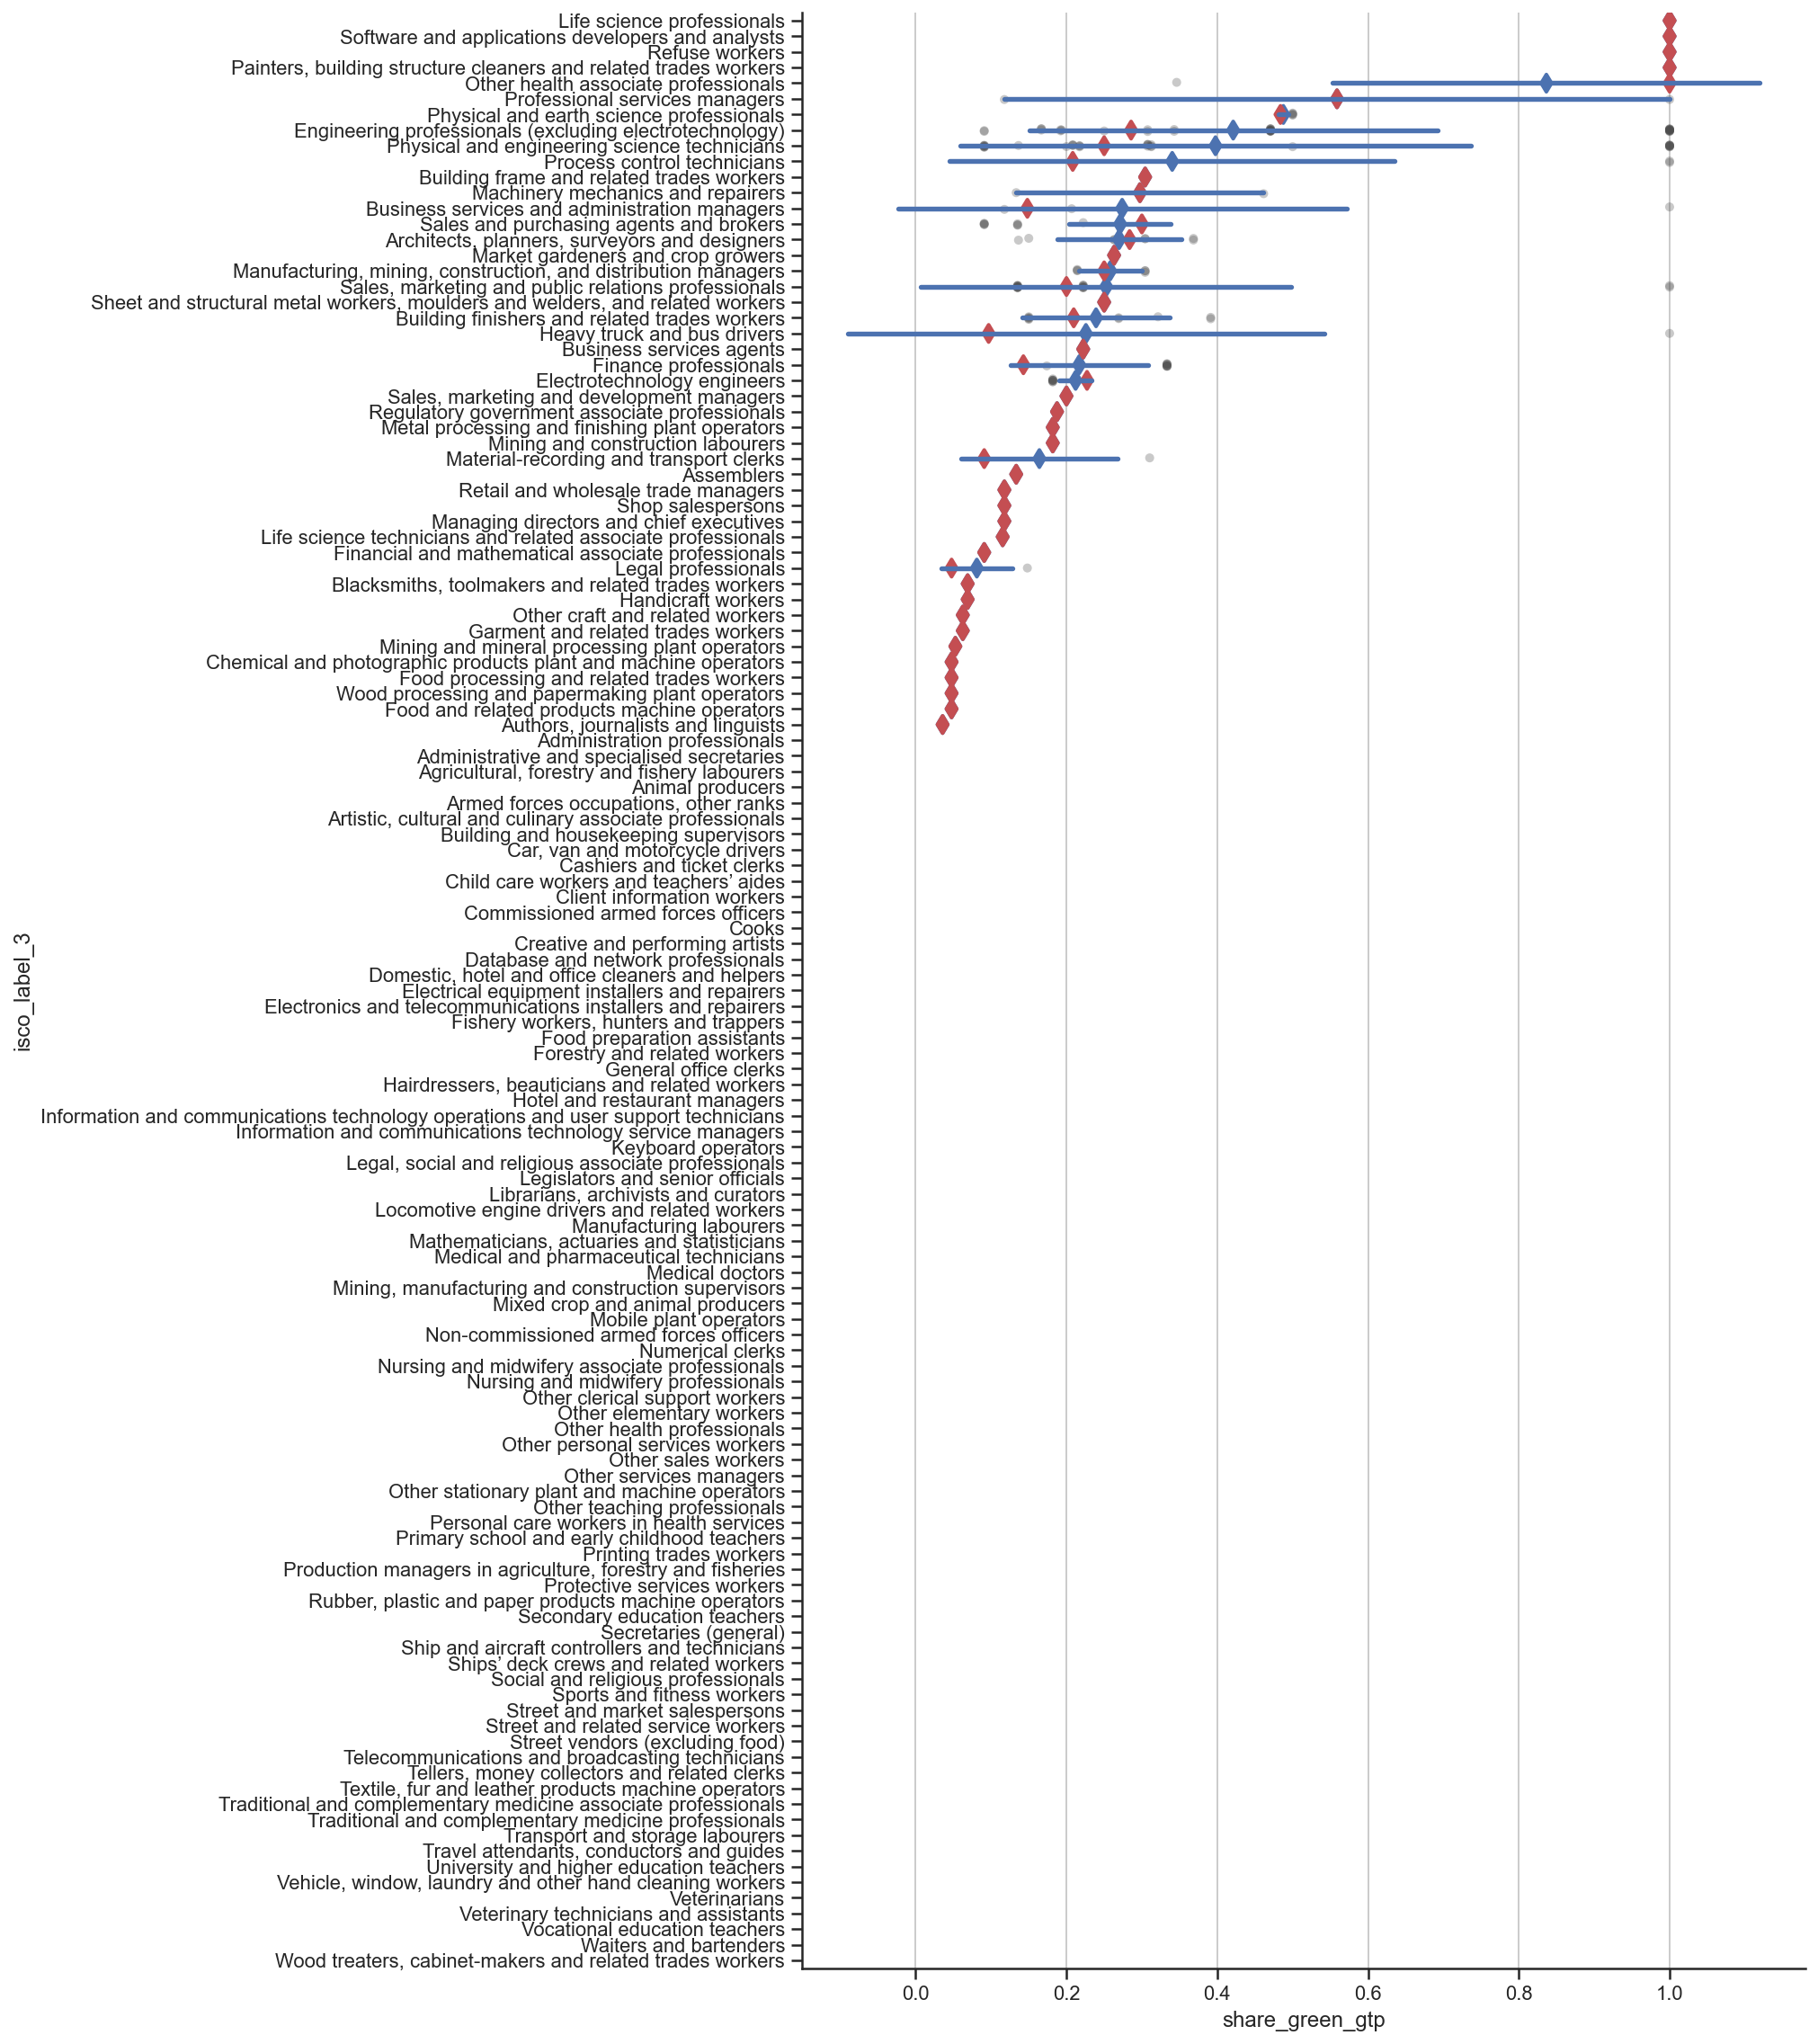

In [220]:
plot_esco_gbn_shares_in_isco_groups(data=omd, x_var="share_green_gtp",
                                    y_var="isco_label_3", figsize=(10, 20))

<AxesSubplot:xlabel='share_brown_esco', ylabel='isco_label_3'>

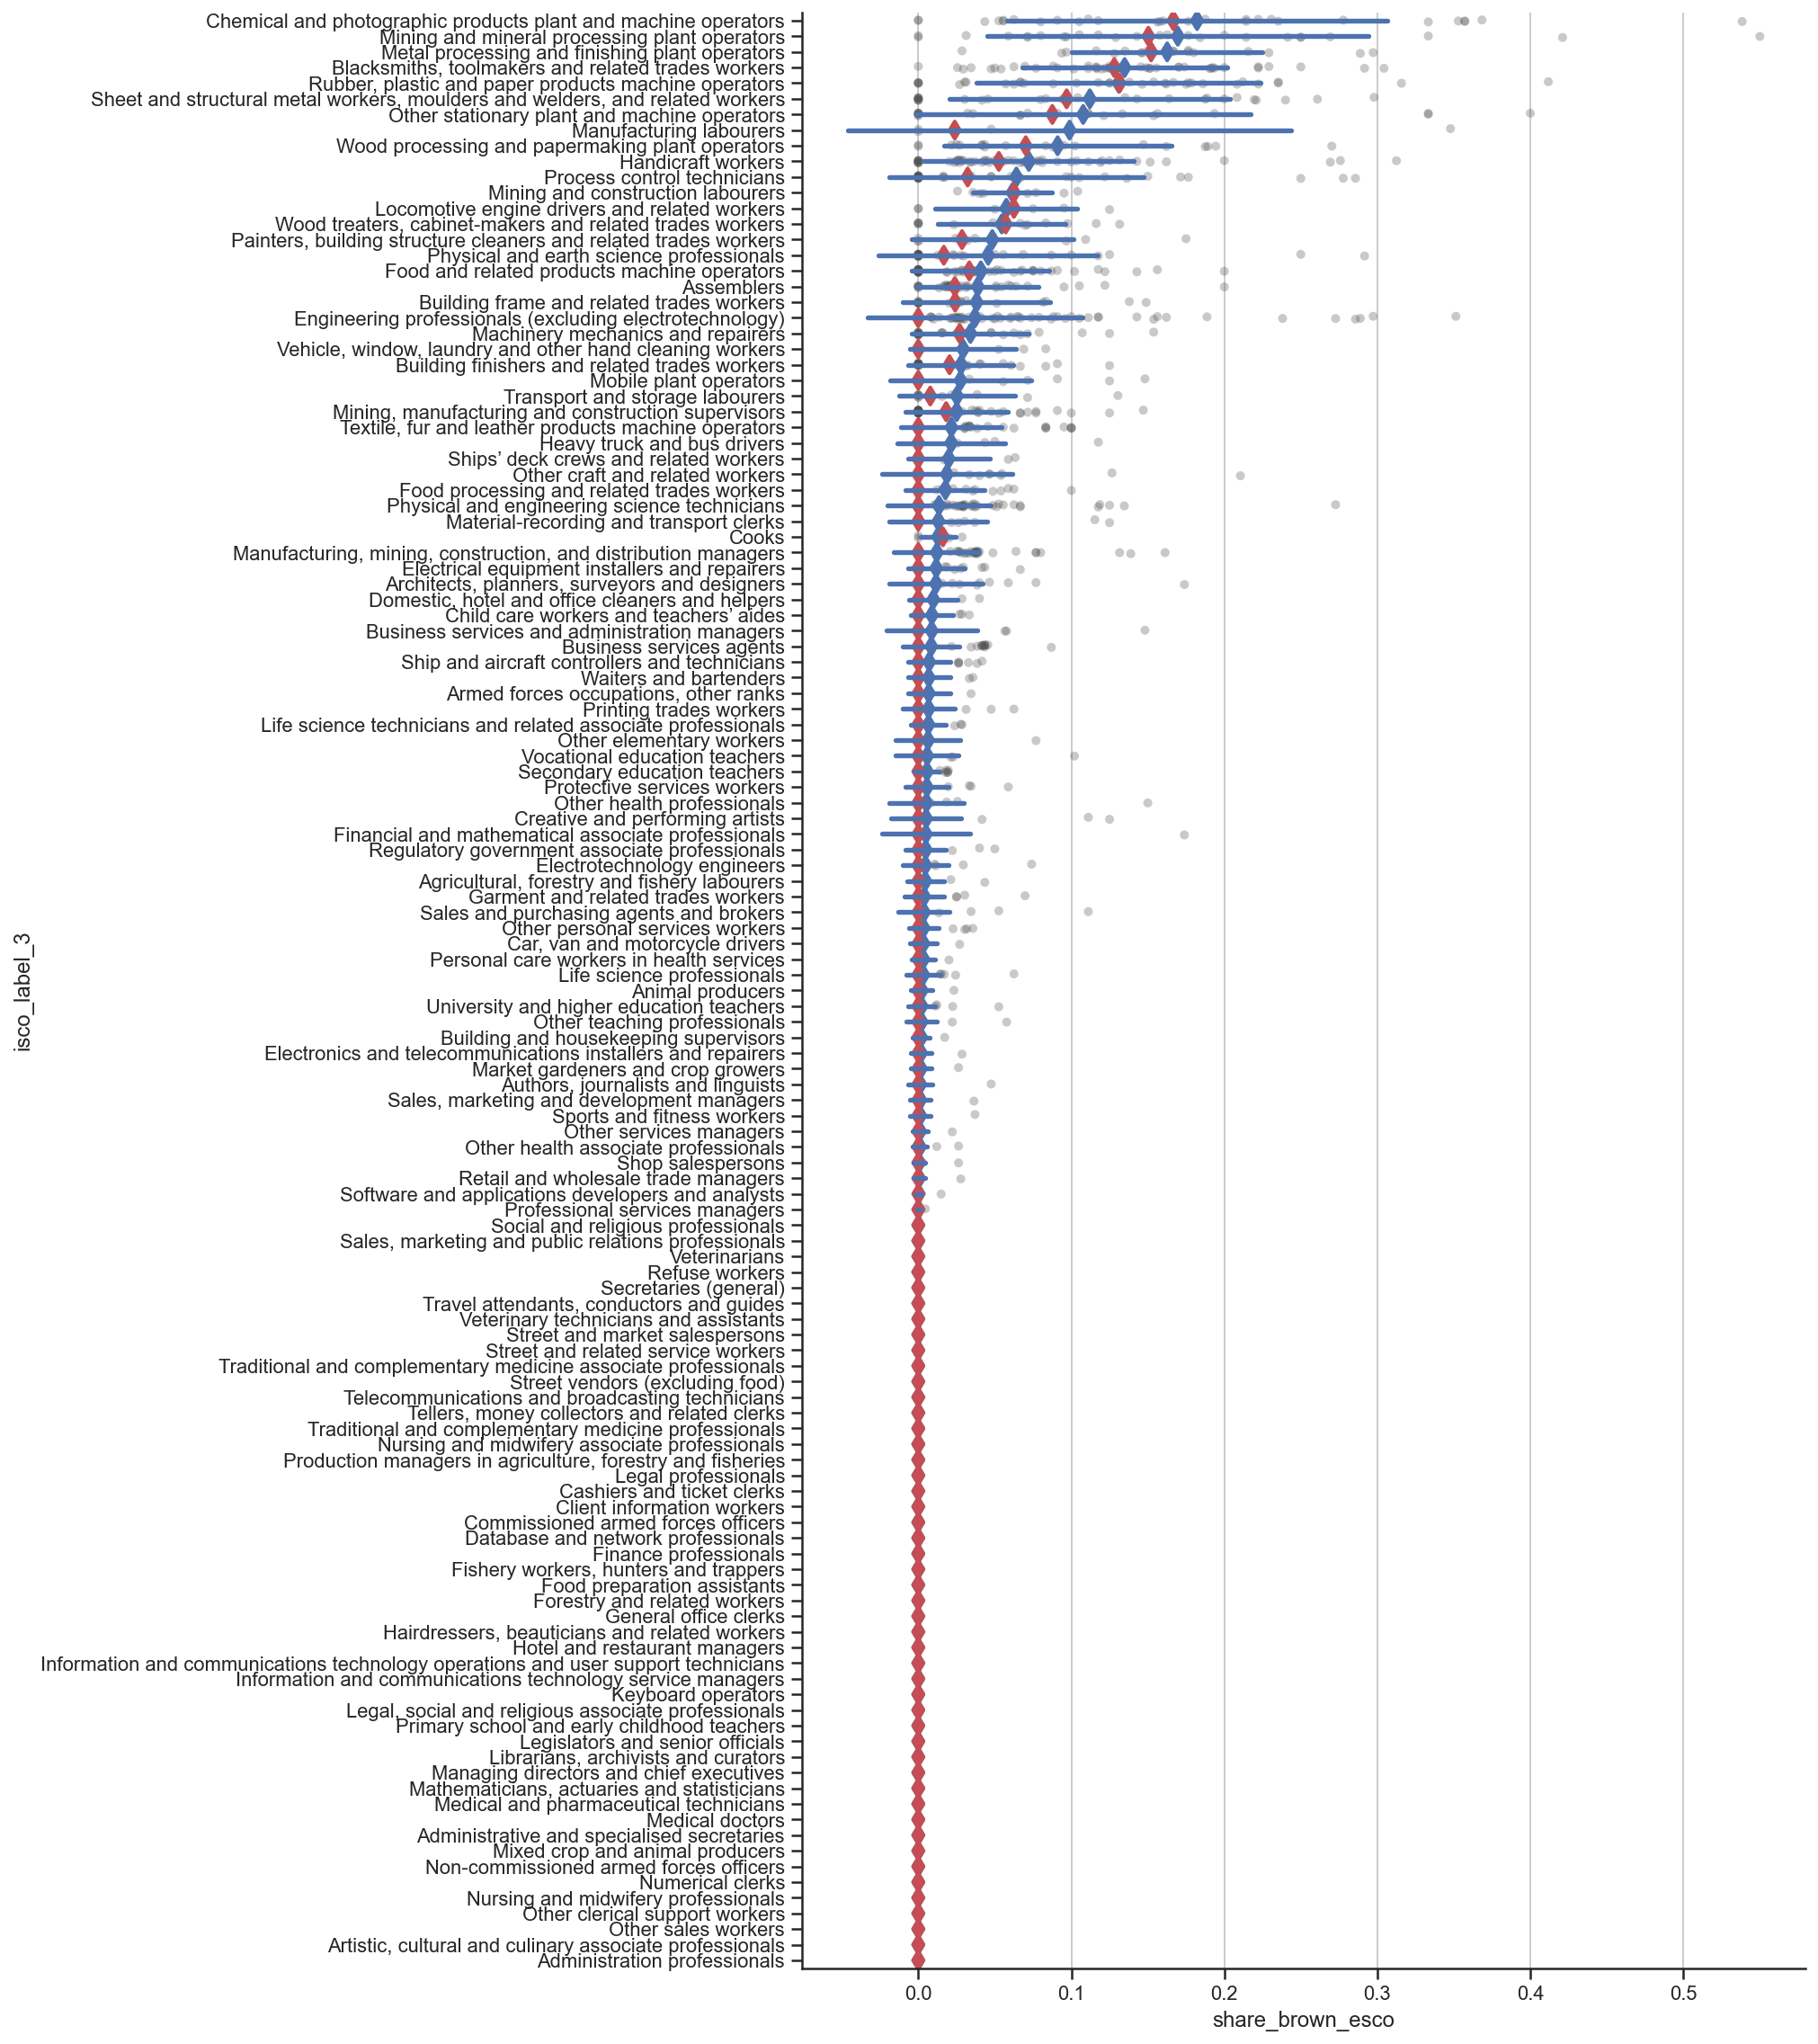

In [221]:
plot_esco_gbn_shares_in_isco_groups(data=omd, x_var="share_brown_esco",
                                    y_var="isco_label_3", figsize=(10, 20))